Step 1: Import Your Toolkit
The Goal: Load the essential libraries into your script
.
What to do:
Import cv2 (OpenCV)
.
Import numpy as np
.
Import matplotlib.pyplot as plt
.

Step 2: Load, Grayscale, and Blur
The Goal: Prepare the image by removing distracting color data and smoothing fine noise
.
What to do:
Load your target image using OpenCV
. (If you don't have a coin image, any photo of a clear object on a contrasting background will work!).
Convert your loaded image from BGR to single-channel Grayscale using cv2.cvtColor()
.
Apply a Gaussian Blur with a kernel size of (5, 5) to smooth out textures and tiny specs that could ruin your thresholding

.
Step 3: Apply Otsu's Automatic Thresholding
The Goal: Let the computer automatically calculate the absolute best threshold value for the lighting in your image
.
What to do:
Call cv2.threshold() on your blurred grayscale image
.
Crucial Settings: Set your threshold argument to 0 and your max value to 255
.
Combine the flags cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU as your threshold type
.
Unpack both outputs: Remember, this function returns two things! Store them as ret, thresh = cv2.threshold(...)
.
Print the automatically calculated threshold (ret) to your console to see what the computer chose
!
What you will see: A binary image where your coins/objects are white and the background is black
.

Step 4: Seal Gaps with Morphological Closing
The Goal: Use shape-based math to fill in any tiny dark scratches, holes, or cracks inside your white objects
.
What to do:
Create a 9x9 structuring kernel of ones using NumPy: np.ones((9, 9), np.uint8)
.
Apply morphological Closing using cv2.morphologyEx() with your binary image, your kernel, the flag cv2.MORPH_CLOSE, and set it to run for 3 iterations
.
What you will see: Your objects will look more solid, and small holes inside them will disappear
.

Step 5: Filter Out Background Dust (Contour Filtering)
The Goal: Trace the boundaries of everything on the screen and delete any shapes that are too small to be your target objects
.
What to do:
Find all outer outlines of your closed binary image using cv2.findContours() with the mode set to cv2.RETR_EXTERNAL and method set to cv2.CHAIN_APPROX_SIMPLE
.
Create a blank, completely black canvas of the exact same size as your grayscale image: result = np.zeros(gray.shape, dtype=np.uint8)
.
Write a loop to go through each contour found
.
Inside the loop, measure the area using cv2.contourArea(contour)
.
If the area is greater than 1000 pixels, draw and fill that contour on your black canvas in white (255) using cv2.fillPoly(result, [contour], 255)
.
What you will see: All tiny white noise specks in the background are instantly deleted, leaving only the large coin outlines on a pure black background
.

Step 6: Fine-Tune with Opening and Erosion
The Goal: Do a final sweep to remove tiny rough edges and refine the shape boundaries
.
What to do:
Create an opening kernel size of 6x6 and apply morphological Opening (cv2.MORPH_OPEN) with 2 iterations to clean up tiny artifacts along the object boundaries
.
Create an erosion kernel size of 9x9 and apply a final Erosion (cv2.erode()) with 2 iterations to shrink and refine the edges back to their true, clean sizes
.

Step 7: Plot the Pipeline Stages
The Goal: Display your progression from a raw image to a perfect segmentation mask
.
What to do:
Set up Matplotlib subplots to show your Original Image, your Otsu Thresholded Image, and your final Cleaned Segmented Image
.
Remember to use cmap='gray' for the single-channel steps so they render in correct black and white
!

In [2]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [3]:
img = cv2.imread(r'C:\Users\Hp\Pictures\OpenCVSamples\car.jpg',0)

In [4]:
def show_img(image , title):
    plt.imshow(image,cmap='gray')
    plt.title(title)
    plt.show()

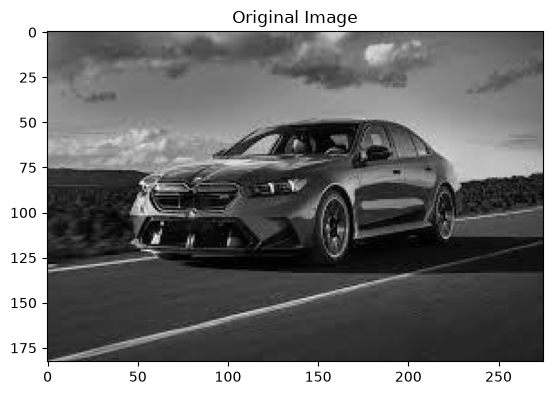

In [5]:
show_img(img,'Original Image')

Otsu thresholding 

The threshold value is not provided by us, instead, Otsu's method determines it automatically based on the image’s histogram. This makes separation of foreground and background particularly strong on bimodal images.

```text
                 Grayscale Image
                       │
                       ▼
                Otsu's Method
                       │
              Calculate threshold
                       │
                       ▼
                 e.g. T = 137
                       │
                       ▼
              Binary Threshold
                ┌──────┴──────┐
                ▼             ▼
            pixel ≤ 137    pixel > 137
                │             │
                ▼             ▼
                0            255

In [8]:
ret , otsu_thresh = cv2.threshold(
    img , 0 , 255 , cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

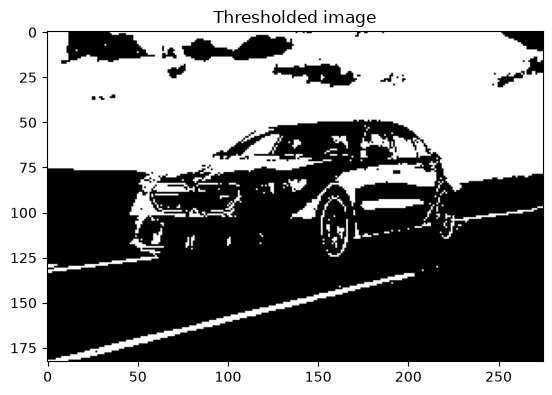

Value of otsu calculated threshold is:  92.0


In [9]:
show_img(otsu_thresh , "Thresholded image")
print("Value of otsu calculated threshold is: ", ret)

Morphological Closing & Background Dilation

Why we use it: Raw thresholding often leaves behind minor imperfections, like tiny dark cracks or holes inside your white objects. We run a closing operation (which dilates then erodes) to seal these small holes and unify nearby regions
. We then dilate (expand) the shapes to stretch their areas out and clarify their boundaries

Closing is particularly useful for:

filling small holes inside objects
connecting small gaps
joining nearby foreground regions

```text
Before closing:

██████   ██████
██████   ██████
██  ██   ██  ██

       ↓

After closing:

██████████████
██████████████
██████████████

In [10]:
kernel = np.ones((9,9),np.uint8)
closing = cv2.morphologyEx(otsu_thresh , cv2.MORPH_CLOSE , kernel , iterations = 3)
bg = cv2.dilate(closing , kernel , iterations = 2)

Contour Filtering & Object Mask Creation

Why we use it: Even after thresholding, there might be tiny white flecks of light in the background. We find the external contours (the outer boundaries of our shapes) and measure their size
. By ignoring any shape with an area smaller than 1,000 pixels, we instantly filter out background dust
. We then paint the remaining major shapes onto a new blank canvas to create a clean, isolated object mask

Take my cleaned binary image →find the boundaries of objects -> find the outer boundaries of objects → create a blank black image → look at every detected object → ignore small objects → fill the large objects in white.

In [ ]:
contours, _ = cv2.findContours(closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

result = np.zeros(img.shape, dtype=np.uint8)

for contour in contours:
    if cv2.contourArea(contour) > 1000:
        cv2.fillPoly(result, [contour], 255)

Morphological Opening & Erosion

Why we use it: Your filtered mask might still have tiny rough bumps on its outer edges. We apply an opening operation to clean up and remove these small foreground artifacts
. Finally, we erode (shrink) the shapes slightly to refine, smooth, and clean up the final boundaries of our segmented objects so they look perfectly natural

In [18]:
kernel_open = np.ones((9,9),np.uint8)
opened = cv2.morphologyEx(result, cv2.MORPH_OPEN , kernel_open , iterations = 3)


kernel_erode = np.ones((9, 9), np.uint8)
final_result = cv2.erode(opened, kernel_erode, iterations=2)

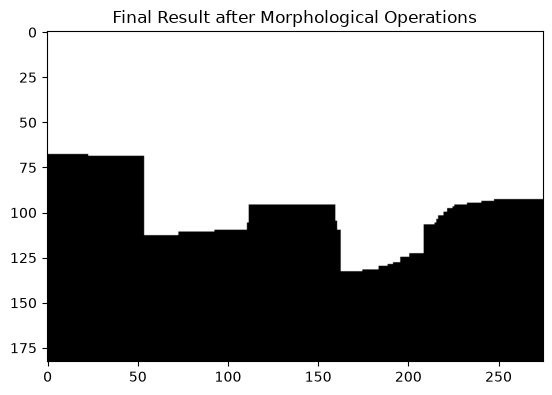

In [19]:
show_img(final_result , "Final Result after Morphological Operations")